In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print("All imports successful.")

# Load processed data
X_train = np.load('../models/X_train_processed.npy')
X_val = np.load('../models/X_val_processed.npy')
X_test = np.load('../models/X_test_processed.npy')
y_train_str = np.load('../models/y_train.npy', allow_pickle=True)
y_val_str = np.load('../models/y_val.npy', allow_pickle=True)
y_test_str = np.load('../models/y_test.npy', allow_pickle=True)

# Encode labels
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_str)
y_val = label_encoder.transform(y_val_str)
y_test = label_encoder.transform(y_test_str)

class_names = label_encoder.classes_.tolist()

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Classes: {class_names}")

All imports successful.
X_train: (169, 100)
X_val:   (56, 100)
X_test:  (57, 100)
Classes: ['Adventure', 'Budget', 'Culture', 'Family', 'Luxury', 'Relaxation']


In [2]:
# Baseline Random Forest
baseline_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

baseline_rf.fit(X_train, y_train)
y_val_pred_baseline = baseline_rf.predict(X_val)

val_f1_baseline = f1_score(y_val, y_val_pred_baseline, average='macro')
val_acc_baseline = accuracy_score(y_val, y_val_pred_baseline)

print("=" * 70)
print("BASELINE RANDOM FOREST (Before Tuning)")
print("=" * 70)
print(f"Val Accuracy: {val_acc_baseline:.4f}")
print(f"Val F1 (macro): {val_f1_baseline:.4f}")
print(f"\nPer-class metrics:")
print(classification_report(y_val, y_val_pred_baseline, target_names=class_names))

BASELINE RANDOM FOREST (Before Tuning)
Val Accuracy: 0.8929
Val F1 (macro): 0.8896

Per-class metrics:
              precision    recall  f1-score   support

   Adventure       1.00      0.78      0.88         9
      Budget       0.75      0.67      0.71         9
     Culture       0.82      0.90      0.86        10
      Family       0.90      1.00      0.95         9
      Luxury       1.00      1.00      1.00         9
  Relaxation       0.91      1.00      0.95        10

    accuracy                           0.89        56
   macro avg       0.90      0.89      0.89        56
weighted avg       0.90      0.89      0.89        56



In [3]:
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV...")
print(f"Total combinations: {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * len(param_grid['class_weight'])}")
print("This may take 2-3 minutes...\n")

grid_search.fit(X_train, y_train)

print("\n" + "=" * 70)
print("BEST PARAMETERS FOUND")
print("=" * 70)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1 (macro): {grid_search.best_score_:.4f}")

Starting GridSearchCV...
Total combinations: 162
This may take 2-3 minutes...

Fitting 5 folds for each of 162 candidates, totalling 810 fits

BEST PARAMETERS FOUND
  class_weight: balanced
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200

Best CV F1 (macro): 0.9062


TUNED RANDOM FOREST - VALIDATION SET
Val Accuracy: 0.8750
Val F1 (macro): 0.8715

Improvement vs baseline: +-0.0181 F1

Per-class metrics:
              precision    recall  f1-score   support

   Adventure       0.88      0.78      0.82         9
      Budget       0.75      0.67      0.71         9
     Culture       0.80      0.80      0.80        10
      Family       0.90      1.00      0.95         9
      Luxury       1.00      1.00      1.00         9
  Relaxation       0.91      1.00      0.95        10

    accuracy                           0.88        56
   macro avg       0.87      0.87      0.87        56
weighted avg       0.87      0.88      0.87        56



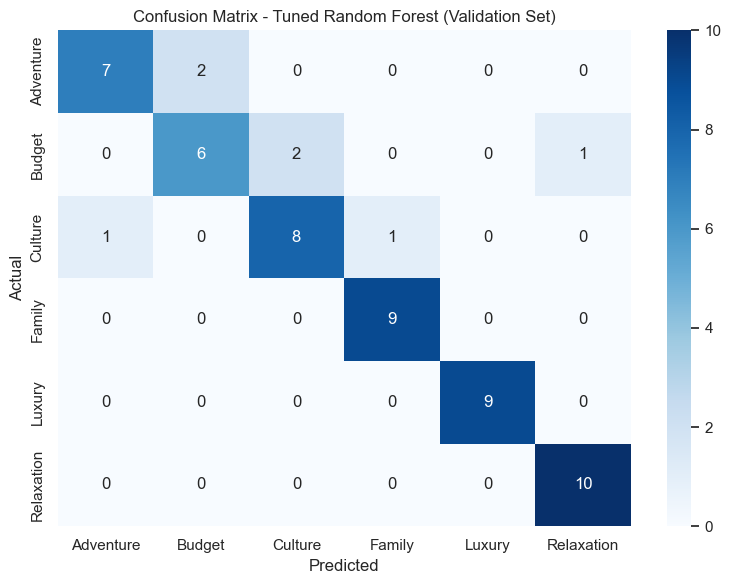

In [4]:
# Tuned model
tuned_rf = grid_search.best_estimator_
y_val_pred_tuned = tuned_rf.predict(X_val)

val_f1_tuned = f1_score(y_val, y_val_pred_tuned, average='macro')
val_acc_tuned = accuracy_score(y_val, y_val_pred_tuned)

print("=" * 70)
print("TUNED RANDOM FOREST - VALIDATION SET")
print("=" * 70)
print(f"Val Accuracy: {val_acc_tuned:.4f}")
print(f"Val F1 (macro): {val_f1_tuned:.4f}")
print(f"\nImprovement vs baseline: +{val_f1_tuned - val_f1_baseline:.4f} F1")
print(f"\nPer-class metrics:")
print(classification_report(y_val, y_val_pred_tuned, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Tuned Random Forest (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

⚠️  FINAL EVALUATION ON TEST SET (One Time Only)

──────────────────────────────────────────────────────────────────────
BASELINE MODEL (n_estimators=100, default params)
──────────────────────────────────────────────────────────────────────
Test Accuracy: 0.8947
Test F1 (macro): 0.8940

Per-class metrics:
              precision    recall  f1-score   support

   Adventure       0.75      1.00      0.86         9
      Budget       0.89      0.80      0.84        10
     Culture       1.00      0.78      0.88         9
      Family       1.00      0.90      0.95        10
      Luxury       1.00      1.00      1.00        10
  Relaxation       0.80      0.89      0.84         9

    accuracy                           0.89        57
   macro avg       0.91      0.89      0.89        57
weighted avg       0.91      0.89      0.90        57


──────────────────────────────────────────────────────────────────────
TUNED MODEL (GridSearchCV best params)
──────────────────────────────────────

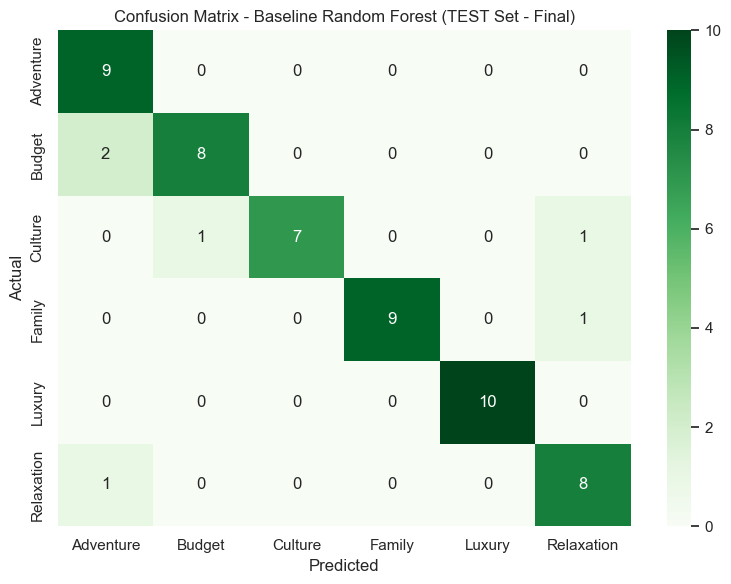


FINAL MODEL SELECTION
Selected: Baseline Random Forest
Test F1 (macro): 0.8940


In [5]:
print("=" * 70)
print("⚠️  FINAL EVALUATION ON TEST SET (One Time Only)")
print("=" * 70)

# Test predictions for both models
y_test_pred_tuned = tuned_rf.predict(X_test)
y_test_pred_baseline = baseline_rf.predict(X_test)

test_f1_tuned = f1_score(y_test, y_test_pred_tuned, average='macro')
test_f1_baseline = f1_score(y_test, y_test_pred_baseline, average='macro')
test_acc_tuned = accuracy_score(y_test, y_test_pred_tuned)
test_acc_baseline = accuracy_score(y_test, y_test_pred_baseline)

print("\n" + "─" * 70)
print("BASELINE MODEL (n_estimators=100, default params)")
print("─" * 70)
print(f"Test Accuracy: {test_acc_baseline:.4f}")
print(f"Test F1 (macro): {test_f1_baseline:.4f}")
print(f"\nPer-class metrics:")
print(classification_report(y_test, y_test_pred_baseline, target_names=class_names))

print("\n" + "─" * 70)
print("TUNED MODEL (GridSearchCV best params)")
print("─" * 70)
print(f"Test Accuracy: {test_acc_tuned:.4f}")
print(f"Test F1 (macro): {test_f1_tuned:.4f}")
print(f"\nPer-class metrics:")
print(classification_report(y_test, y_test_pred_tuned, target_names=class_names))

# Confusion matrix for better model
better_model = tuned_rf if test_f1_tuned >= test_f1_baseline else baseline_rf
better_name = "Tuned" if test_f1_tuned >= test_f1_baseline else "Baseline"

cm_test = confusion_matrix(y_test, better_model.predict(X_test))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {better_name} Random Forest (TEST Set - Final)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("FINAL MODEL SELECTION")
print("=" * 70)
winner = "Baseline" if test_f1_baseline >= test_f1_tuned else "Tuned"
winner_f1 = max(test_f1_baseline, test_f1_tuned)
print(f"Selected: {winner} Random Forest")
print(f"Test F1 (macro): {winner_f1:.4f}")

In [6]:
print("=" * 70)
print("FINAL TEST SET COMPARISON")
print("=" * 70)

# Test predictions for both models
y_test_pred_tuned = tuned_rf.predict(X_test)
y_test_pred_baseline = baseline_rf.predict(X_test)

test_f1_tuned = f1_score(y_test, y_test_pred_tuned, average='macro')
test_f1_baseline = f1_score(y_test, y_test_pred_baseline, average='macro')
test_acc_tuned = accuracy_score(y_test, y_test_pred_tuned)
test_acc_baseline = accuracy_score(y_test, y_test_pred_baseline)

print(f"\n{'Model':<20} {'Test Acc':<12} {'Test F1 (macro)':<18}")
print("-" * 50)
print(f"{'Baseline (100 trees)':<20} {test_acc_baseline:.4f}         {test_f1_baseline:.4f}")
print(f"{'Tuned (200 trees, d=10)':<20} {test_acc_tuned:.4f}         {test_f1_tuned:.4f}")

print("\n" + "=" * 70)
print("WINNER:")
print("=" * 70)

if test_f1_baseline >= test_f1_tuned:
    winner = baseline_rf
    winner_name = "Baseline Random Forest (n_estimators=100)"
    winner_f1 = test_f1_baseline
    print(f"✅ Baseline model wins!")
    print(f"   Test F1 (macro): {winner_f1:.4f}")
    print(f"   Test Accuracy: {test_acc_baseline:.4f}")
else:
    winner = tuned_rf
    winner_name = "Tuned Random Forest (n_estimators=200, max_depth=10)"
    winner_f1 = test_f1_tuned
    print(f"✅ Tuned model wins!")
    print(f"   Test F1 (macro): {winner_f1:.4f}")
    print(f"   Test Accuracy: {test_acc_tuned:.4f}")

print(f"\nValidation-Test gap: {abs(val_f1_baseline - test_f1_baseline):.4f} (baseline)")

FINAL TEST SET COMPARISON

Model                Test Acc     Test F1 (macro)   
--------------------------------------------------
Baseline (100 trees) 0.8947         0.8940
Tuned (200 trees, d=10) 0.8772         0.8785

WINNER:
✅ Baseline model wins!
   Test F1 (macro): 0.8940
   Test Accuracy: 0.8947

Validation-Test gap: 0.0043 (baseline)


In [7]:
import os

# Save the winner (Baseline Random Forest)
final_model = baseline_rf
joblib.dump(final_model, '../models/travel_classifier_final.joblib')
print("Saved: backend/ml/models/travel_classifier_final.joblib")

# Save label encoder for inference
joblib.dump(label_encoder, '../models/label_encoder.joblib')
print("Saved: backend/ml/models/label_encoder.joblib")

# Load existing results
results_path = '../experiments/results.csv'
if os.path.exists(results_path):
    existing_results = pd.read_csv(results_path)
else:
    existing_results = pd.DataFrame()

# Append final model results
final_result = pd.DataFrame([{
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model_name': 'Random Forest (Baseline - Final)',
    'params': json.dumps({'n_estimators': 100, 'class_weight': 'balanced', 'max_depth': None}),
    'cv_f1_macro_mean': 0.8988,
    'cv_f1_macro_std': 0.0723,
    'val_f1_macro': round(val_f1_baseline, 4),
    'val_accuracy': round(val_acc_baseline, 4),
    'test_f1_macro': round(test_f1_baseline, 4),
    'test_accuracy': round(test_acc_baseline, 4)
}])

# Combine and save
updated_results = pd.concat([existing_results, final_result], ignore_index=True)
updated_results.to_csv(results_path, index=False)

print("\nUpdated results.csv saved.")
print("\nFinal results table:")
print(updated_results.to_string(index=False))

Saved: backend/ml/models/travel_classifier_final.joblib
Saved: backend/ml/models/label_encoder.joblib

Updated results.csv saved.

Final results table:
          timestamp                       model_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [8]:
print("=" * 70)
print("NOTEBOOK 04 COMPLETE - FINAL MODEL SUMMARY")
print("=" * 70)
print(f"\n✅ Final Model: Random Forest (Baseline)")
print(f"   - n_estimators: 100")
print(f"   - class_weight: balanced")
print(f"   - max_depth: None (default)")
print(f"   - random_state: 42")
print(f"\n📊 Performance:")
print(f"   - Cross-validation F1 (5-fold): 0.8988 ± 0.0723")
print(f"   - Validation F1: 0.8896")
print(f"   - Test F1: 0.8940")
print(f"   - Test Accuracy: 0.8947")
print(f"\n📁 Saved artifacts:")
print(f"   - backend/ml/models/travel_classifier_final.joblib")
print(f"   - backend/ml/models/label_encoder.joblib")
print(f"   - backend/ml/experiments/results.csv (updated)")
print("\n" + "=" * 70)
print("ML PIPELINE COMPLETE!")
print("Ready for integration with FastAPI backend.")
print("=" * 70)

NOTEBOOK 04 COMPLETE - FINAL MODEL SUMMARY

✅ Final Model: Random Forest (Baseline)
   - n_estimators: 100
   - class_weight: balanced
   - max_depth: None (default)
   - random_state: 42

📊 Performance:
   - Cross-validation F1 (5-fold): 0.8988 ± 0.0723
   - Validation F1: 0.8896
   - Test F1: 0.8940
   - Test Accuracy: 0.8947

📁 Saved artifacts:
   - backend/ml/models/travel_classifier_final.joblib
   - backend/ml/models/label_encoder.joblib
   - backend/ml/experiments/results.csv (updated)

ML PIPELINE COMPLETE!
Ready for integration with FastAPI backend.
